In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/cleaned_crop_data.csv")

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,NPK_Total,NPK_Average,Humidity_Temp_Index,Soil_Fertility,Rainfall_Category
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,175,58.333333,1712.196283,61.5,High
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,184,61.333333,1748.595734,63.7,High
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,159,53.000000,1893.744627,53.7,High
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,149,49.666667,2123.482908,52.1,High
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,162,54.000000,1642.720357,56.4,High


## Encode Target

In [3]:
le = LabelEncoder()

df["label"] = le.fit_transform(df["label"])

## Features & TargetFeatures & Target

In [4]:
X = df.drop("label", axis=1)

y = df["label"]

## Handle Rainfall Category

Since we created a categorical feature:

In [5]:
X = pd.get_dummies(
    X,
    columns=["Rainfall_Category"],
    drop_first=True
)

## Train Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Scale Data

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Create Models

In [8]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=500),

    "Decision Tree":
        DecisionTreeClassifier(),

    "Random Forest":
        RandomForestClassifier(),

    "Gradient Boosting":
        GradientBoostingClassifier(),

    "XGBoost":
        XGBClassifier(
            eval_metric="mlogloss"
        )
}

## Train All Models

In [9]:
results = []

for name, model in models.items():

    model.fit(
        X_train_scaled,
        y_train
    )

    y_pred = model.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

## Model Comparison Table

In [10]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
4,XGBoost,0.995455,0.995671,0.995455,0.995452
2,Random Forest,0.990909,0.991539,0.990909,0.990895
3,Gradient Boosting,0.988636,0.989742,0.988636,0.988723
1,Decision Tree,0.981818,0.982643,0.981818,0.981852
0,Logistic Regression,0.979545,0.980654,0.979545,0.979455


## Cross Validation

In [11]:
cv_scores = {}

for name, model in models.items():

    score = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    cv_scores[name] = score.mean()

cv_scores

{'Logistic Regression': np.float64(0.9540909090909091),
 'Decision Tree': np.float64(0.9881818181818183),
 'Random Forest': np.float64(0.9945454545454545),
 'Gradient Boosting': np.float64(0.9895454545454546),
 'XGBoost': np.float64(0.9927272727272728)}

## Hyperparameter Tuning

In [12]:
param_grid = {

    "n_estimators":
        [100,200,300],

    "max_depth":
        [5,10,15,None],

    "min_samples_split":
        [2,5,10]
}

In [13]:
rf = RandomForestClassifier()

random_search = RandomizedSearchCV(

    estimator=rf,

    param_distributions=param_grid,

    n_iter=10,

    cv=5,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1
)

random_search.fit(
    X_train_scaled,
    y_train
)

print(
    random_search.best_params_
)

print(
    random_search.best_score_
)

{'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 15}
0.9926136363636363


## Best Model

In [19]:
best_model = models["XGBoost"]

In [20]:
y_pred = best_model.predict(
    X_test_scaled
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      0.95      0.97        20
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        20
          13       0.95      1.00      0.98        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

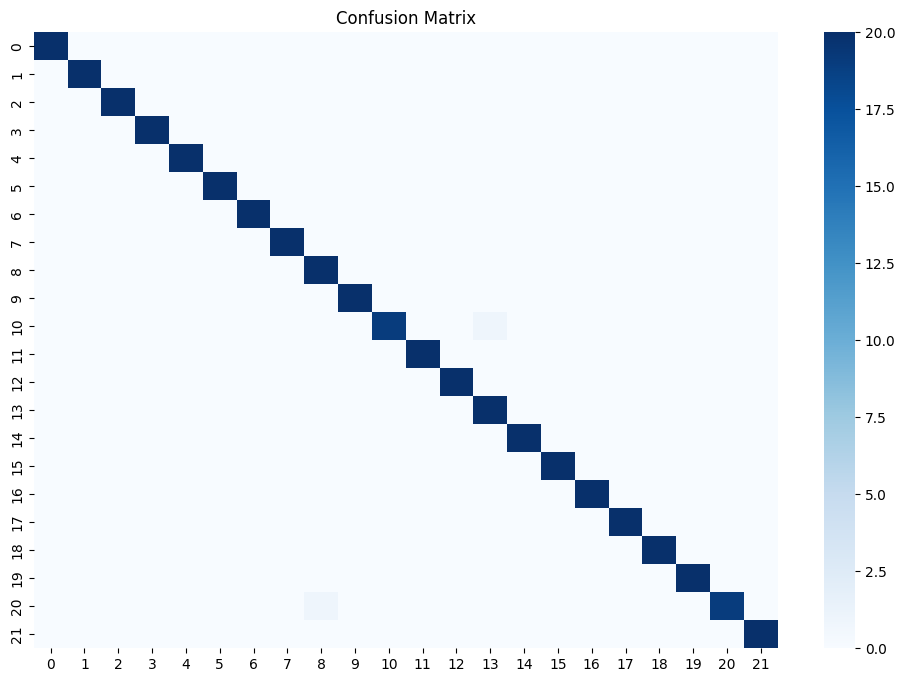

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

In [22]:
joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

joblib.dump(
    le,
    "../models/label_encoder.pkl"
)

print(
    "Models Saved Successfully"
)

Models Saved Successfully


In [23]:
print("="*50)

print("MODEL TRAINING COMPLETED")

print("="*50)

print("Total Models Trained : 5")

print("Cross Validation : Completed")

print("Hyperparameter Tuning : Completed")

print("Model Saved : Yes")

MODEL TRAINING COMPLETED
Total Models Trained : 5
Cross Validation : Completed
Hyperparameter Tuning : Completed
Model Saved : Yes
